# Lab 1: Train and Convert a Lightweight ML Model for Edge Deployment Using TensorFlow Lite

### Objective:
The objective of this lab is to train a simple neural network model using TensorFlow on the MNIST dataset 
and convert it into a lightweight TensorFlow Lite (TFLite) model for potential deployment on edge devices.

### Pre-requisites:
- Basic understanding of Python and Jupyter Notebooks
- Familiarity with Machine Learning and Neural Networks
- TensorFlow and NumPy installed in the environment

In [7]:
# Step 1: Import Required Libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

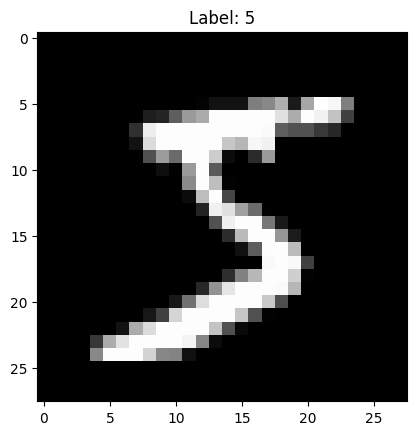

In [8]:
# Step 2: Load and Explore the Dataset (MNIST)
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Display sample image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [9]:
# Step 3: Define and Train a Simple Model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

Epoch 1/5


c:\Users\bhawa\miniconda3\envs\dataScience\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8691 - loss: 0.4523 - val_accuracy: 0.9663 - val_loss: 0.1251
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9649 - loss: 0.1136 - val_accuracy: 0.9715 - val_loss: 0.0908
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9773 - loss: 0.0753 - val_accuracy: 0.9787 - val_loss: 0.0758
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9824 - loss: 0.0559 - val_accuracy: 0.9765 - val_loss: 0.0835
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9870 - loss: 0.0400 - val_accuracy: 0.9800 - val_loss: 0.0712
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9747 - loss: 0.0852

Test Accuracy: 0.9779


In [10]:
# Step 4: Save the Model
model.save("mnist_model.keras")

In [11]:
# Step 5: Convert the Model to TensorFlow Lite Format

# load the model
model = tf.keras.models.load_model('mnist_model.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted TFLite model
with open("mnist_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model successfully converted to TensorFlow Lite!")

INFO:tensorflow:Assets written to: C:\Users\bhawa\AppData\Local\Temp\tmpg2xyvy_7\assets


INFO:tensorflow:Assets written to: C:\Users\bhawa\AppData\Local\Temp\tmpg2xyvy_7\assets


Saved artifact at 'C:\Users\bhawa\AppData\Local\Temp\tmpg2xyvy_7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1993031881488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993080101136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993080099600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993080101520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993080101712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1993080102288: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model successfully converted to TensorFlow Lite!


In [12]:
# Step 6: Load and Test the TFLite Model (Simulated Inference)
# Load the TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path="mnist_model.tflite")
interpreter.allocate_tensors()

# Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prepare one test image
input_data = np.expand_dims(x_test[0], axis=0).astype(np.float32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

print(f"Predicted Label: {predicted_label}")
print(f"Actual Label: {y_test[0]}")

Predicted Label: 7
Actual Label: 7


C:\Users\bhawa\AppData\Roaming\Python\Python311\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
